In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Ordinary Least Squares (OLS) Regression

| Code | Description |
| --- | --- |
| `X = np.random.randn(10, 1)` | Create a 10-by-1 array of random numbers called `X` |
| `X = np.random.randn(10, 3)` | Create a 10-by-3 array of random numbers called `X` |
| `np.ones((10, 1))` | Create 10-by-1 array of ones |
| `np.hstack((np.ones(10, 1), X))` | Stack a column of ones to the left side of `X`|
| `X.T` | Transpose the matrix `X` |
| `X.T @ X` | Multiply the matrix `X` with it's transpose |
| `y = y[:, np.newaxis`] | Add an empty dimension to `y` |
| `np.linalg.solve(X.T @ X, X.T @ y)` | Solve the equation $\beta = (X^T X)^{-1} X^T y$ |
| `plt.plot(x, y)` | Create a line plot for `x` and `y` |
| `plt.scatter(x, y)` | Create a scatter plot for `x` and `y` |

In [ ]:
np.random.seed(42)
X = 2 * np.random.rand(100 , 1)
y = 3 * X + np.random.randn(100 , 1)
plt.scatter(X, y)

$$\beta = (X^T X)^{-1} X^T y$$

In [ ]:
beta = np.linalg.solve(X.T @ X, X.T @ y)
beta

In [ ]:
X.shape

In [ ]:
plt.scatter(X, y)
plt.plot(X, X @ beta)

With intercept

In [ ]:

X = 2 * np.random.rand(100 , 1)
y = 2+ 3 * X + np.random.randn(100 , 1) * 0.5
plt.scatter(X, y)

In [ ]:
beta = np.linalg.solve(X.T @ X, X.T @ y)
plt.scatter(X, y)
plt.plot(X, X @ beta)

In [ ]:
X = np.hstack((np.ones((100, 1)), X))

In [ ]:
beta = np.linalg.solve(X.T @ X, X.T @ y)
beta

In [ ]:
plt.scatter(X[:, 1:], y)
plt.plot(X[:,1:], X @ beta)

In [ ]:
X = np.random.randn(100, 3)
X = np.hstack((np.ones((100, 1)), X))
y = 2 + 3*X[:,1] - 1.5*X[:,2] + 0.8*X[:,3] + np.random.randn(100)
y = y[:, np.newaxis]

fig, ax = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
ax[0].scatter(X[:,1], y)
ax[0].set(xlabel="X1", ylabel="y")
ax[1].scatter(X[:,2], y)
ax[1].set(xlabel="X2")
ax[2].scatter(X[:,3], y)
ax[2].set(xlabel="X3")

In [ ]:
beta = np.linalg.solve(X.T @ X, X.T @ y)
beta


In [ ]:
feature = 1
plt.scatter(X[:,feature], y)
plt.plot(X[:, feature], X[:, [0, feature]] @ beta[[0, feature]])


In [ ]:
feature = 2
plt.scatter(X[:,feature], y)
plt.plot(X[:, feature], X[:, [0, feature]] @ beta[[0, feature]])

In [ ]:
feature = 3
plt.scatter(X[:,feature], y)
plt.plot(X[:, feature], X[:, [0, feature]] @ beta[[0, feature]])

## Making Robust Predictions with Ridge Regularization

| Code | Description |
| --- | -- |
| `I = np.eye(4)` | Create a 4-by-4 identity matrix |
| `np.sqrt(np.mean((y-y_pred)**2))` | Calculate the mean squared error (MSE) for `y` and `y_pred` |
| `lam = 0.1` | Set the regularization coefficient $\lambda$ to `0.1` |
| `b = np.linalg.solve(X.T @ X + lam * I, X.T @ y)` | Solve the equation $\beta=(X^T X + \lambda I)^{-1} X^T y$

In [ ]:
X = np.random.randn(100, 5)
y = 2 + 3*X[:,0] - 1.5*X[:,1] + 0.8*X[:,2] + 0*X[:,3] + -0.5*X[:,4] + np.random.randn(100)
y = y[:, np.newaxis]

X.shape, y.shape

In [ ]:
n_train = 15
n_test = X.shape[0]-n_train

X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

In [ ]:
beta = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
beta

In [ ]:
y_train_pred = X_train @ beta
np.sqrt(np.mean((y_train-y_train_pred)**2))

In [ ]:
y_test_pred = X_test @ beta
np.sqrt(np.mean((y_test-y_test_pred)**2))

$$\beta = (X^T X + \lambda I)^{-1} X^T y$$

minimizes

$$\min_\beta \left( ||y - X\beta||^2 + \lambda ||\beta||^2 \right)$$

In [ ]:
I = np.eye(X.shape[1])
I[0, 0] = 0
lam = 0.2
beta = np.linalg.solve(X_train.T @ X_train + lam * I, X_train.T @ y_train)
beta

In [ ]:
mse_test = []
mse_train = []
lambdas = np.linspace(0.1, 2, 20)
for lam in lambdas:
    beta = np.linalg.solve(X_train.T @ X_train + lam * I, X_train.T @ y_train)
    y_test_pred = X_test @ beta
    mse_test.append(np.sqrt(np.mean((y_test-y_test_pred)**2)))
    y_train_pred = X_train @ beta
    mse_train.append(np.sqrt(np.mean((y_train-y_train_pred)**2)))

fig, ax = plt.subplots(1,2, figsize=(8,3))
ax[0].plot(lambdas, mse_train)
ax[0].set(xlabel="$\lambda$", ylabel="MSE", title="Training Data")
ax[1].plot(lambdas, mse_test)
ax[1].set(xlabel="$\lambda$", title="Test Data")

## Cross-Validation

| Code | Description |
| --- | --- |
| `np.arange(10)` | Return an array of integers between 0 and (not including) 10 |
| `np.array_split(X, 4)` | Split `X` into `4` arrays of (approximately) equal length |
| `np.concatenate(a, b)` | Concatenate the arrays `a` and `b` along the 1st dimension |

In [ ]:
X = np.random.randn(100, 5)
y = 3*X[:,0] - 1.5*X[:,1] + 0.8*X[:,2] + 0*X[:,3] + -0.5*X[:,4] + np.random.randn(100)
y = y[:, np.newaxis]

X.shape, y.shape

((100, 5), (100, 1))

In [ ]:
n_splits = 5
X_split = np.array_split(X, n_splits)
y_split = np.array_split(y, n_splits)

X_split[0].shape, X_split[1].shape


In [ ]:
idx = np.arange(n_splits)
np.random.shuffle(idx)
X_split = [X_split[i] for i in idx]
y_split = [y_split[i] for i in idx]

In [61]:
lam = 5
mse = []
for i in range(n_splits):
    X_test = X_split[i]
    y_test = y_split[i]
    X_train = np.concatenate(X_split[:i] + X_split[i+1:])
    y_train = np.concatenate(y_split[:i] + y_split[i+1:])
    
    I = np.eye(X.shape[1])
    I[0, 0] = 0
    beta = np.linalg.solve(X_train.T @ X_train + lam * I, X_train.T @ y_train)
    y_test_pred = X_test @ beta

    mse.append(np.sqrt(np.mean((y_test-y_test_pred)**2)))

np.mean(mse)

    
    



np.float64(2.3307403845057406)

## Finding the best Value for Lambda

| Code | Description |
| --- | --- |
| `np.linspace(1, 10, 3)` | Return an array with 3 equally spaced values between `1` and `10` |
| `np.logspace(-2, 3, 5)` | Return an array with 3 logarithmically spaced values between $10^{-2}$ and $10^3$ |

In [ ]:
lambdas = np.linspace(0.1, 20, 10)
mse_per_lambda = []
for lam in lambdas:
    mse = []
    for i in range(n_splits):
        X_test = X_split[i]
        y_test = y_split[i]
        X_train = np.concatenate(X_split[:i] + X_split[i+1:])
        y_train = np.concatenate(y_split[:i] + y_split[i+1:])
        
        I = np.eye(X.shape[1])
        I[0, 0] = 0
        beta = np.linalg.solve(X_train.T @ X_train + lam * I, X_train.T @ y_train)
        y_test_pred = X_test @ beta

        mse.append(np.sqrt(np.mean((y_test-y_test_pred)**2)))
    mse_per_lambda.append(np.mean(mse))


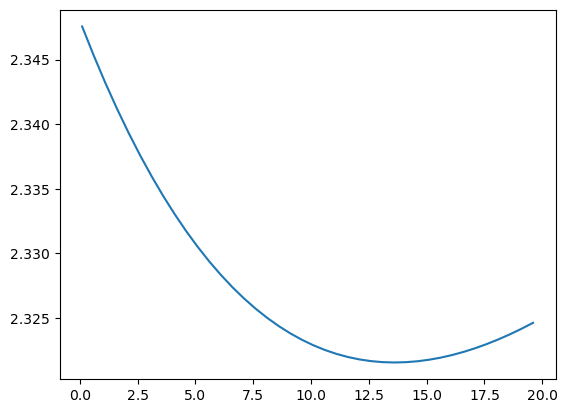

In [65]:
plt.plot(lambdas, mse_per_lambda)